In [ ]:
# Install required libraries
!pip install pandas numpy matplotlib seaborn

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [ ]:
# Column names for NSL-KDD dataset
columns = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes',
    'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
    'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell',
    'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
    'num_access_files', 'num_outbound_cmds', 'is_host_login',
    'is_guest_login', 'count', 'srv_count', 'serror_rate',
    'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
    'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
    'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate',
    'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
    'dst_host_srv_rerror_rate', 'label', 'difficulty'
]

# Load training data
train_df = pd.read_csv(
    'https://raw.githubusercontent.com/logesh-GIT001/Smart-SOC/main/data/raw/KDDTrain%2B.txt',
    names=columns
)

# Load test data
test_df = pd.read_csv(
    'https://raw.githubusercontent.com/logesh-GIT001/Smart-SOC/main/data/raw/KDDTest%2B.txt',
    names=columns
)

print(f"✅ Train set: {train_df.shape}")
print(f"✅ Test set:  {test_df.shape}")

✅ Train set: (125973, 43)
✅ Test set:  (22544, 43)


In [ ]:
# First look at the data
print("=== First 5 rows ===")
print(train_df.head())

print("\n=== Shape ===")
print(f"Rows: {train_df.shape[0]}, Columns: {train_df.shape[1]}")

print("\n=== Data Types ===")
print(train_df.dtypes)

print("\n=== Missing Values ===")
print(train_df.isnull().sum().sum(), "missing values found")

=== First 5 rows ===
   duration protocol_type   service flag  src_bytes  dst_bytes  land  \
0         0           tcp  ftp_data   SF        491          0     0   
1         0           udp     other   SF        146          0     0   
2         0           tcp   private   S0          0          0     0   
3         0           tcp      http   SF        232       8153     0   
4         0           tcp      http   SF        199        420     0   

   wrong_fragment  urgent  hot  ...  dst_host_same_srv_rate  \
0               0       0    0  ...                    0.17   
1               0       0    0  ...                    0.00   
2               0       0    0  ...                    0.10   
3               0       0    0  ...                    1.00   
4               0       0    0  ...                    1.00   

   dst_host_diff_srv_rate  dst_host_same_src_port_rate  \
0                    0.03                         0.17   
1                    0.60                         0

In [ ]:
# How many types of attacks do we have?
print("=== Attack Types ===")
print(train_df['label'].value_counts())

print(f"\nTotal unique labels: {train_df['label'].nunique()}")

=== Attack Types ===
label
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64

Total unique labels: 23


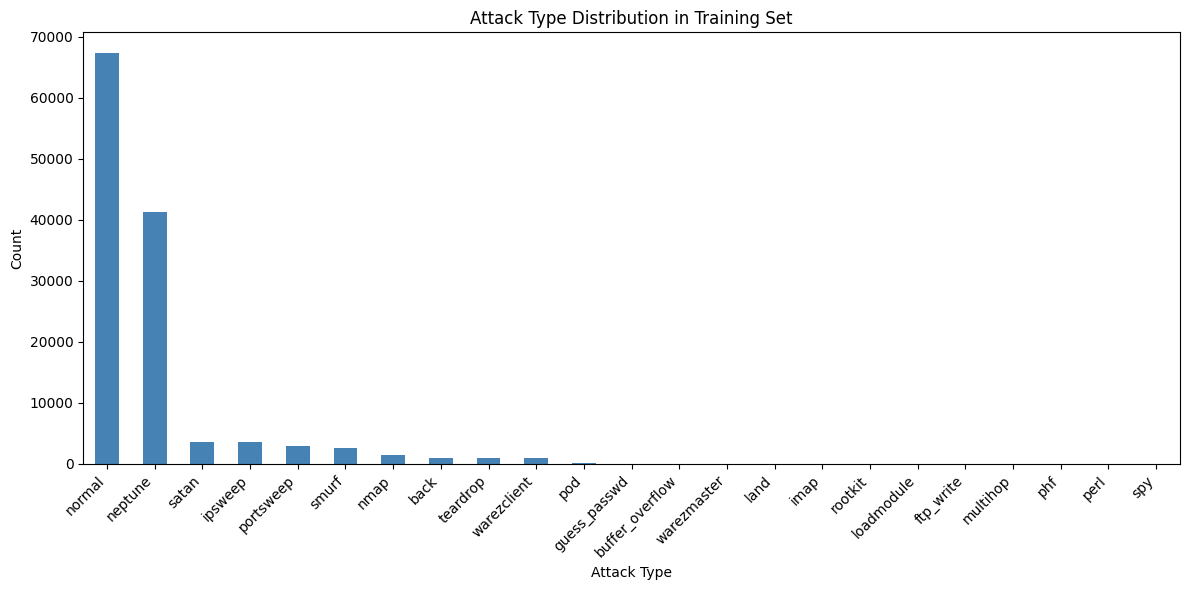

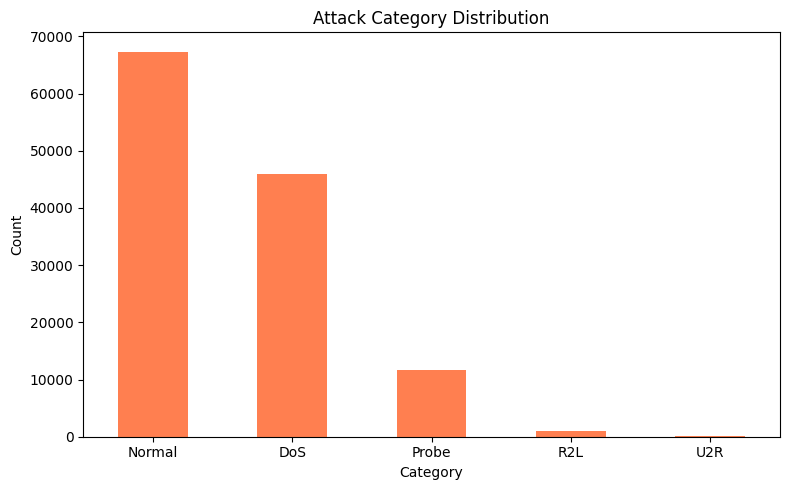

category
Normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64


In [ ]:
# Plot attack type distribution
plt.figure(figsize=(12, 6))
train_df['label'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Attack Type Distribution in Training Set')
plt.xlabel('Attack Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Group into main categories
def categorize(label):
    dos = ['neptune','back','land','pod','smurf','teardrop']
    probe = ['ipsweep','nmap','portsweep','satan']
    r2l = ['ftp_write','guess_passwd','imap','multihop','phf','spy','warezclient','warezmaster']
    u2r = ['buffer_overflow','loadmodule','perl','rootkit']
    if label == 'normal': return 'Normal'
    elif label in dos: return 'DoS'
    elif label in probe: return 'Probe'
    elif label in r2l: return 'R2L'
    elif label in u2r: return 'U2R'
    else: return 'Unknown'

train_df['category'] = train_df['label'].apply(categorize)

plt.figure(figsize=(8, 5))
train_df['category'].value_counts().plot(kind='bar', color='coral')
plt.title('Attack Category Distribution')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(train_df['category'].value_counts())

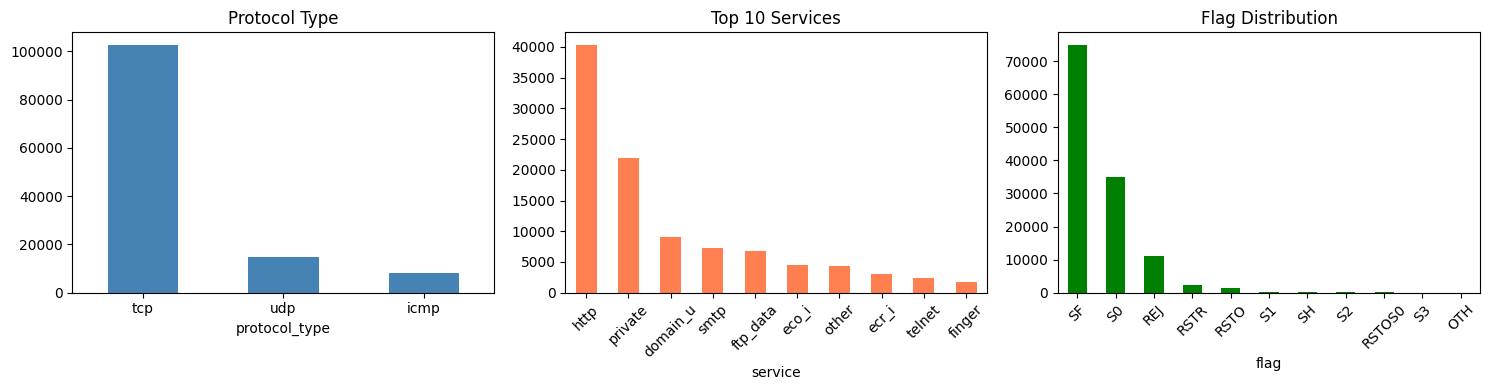

In [ ]:
# Protocol type distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Protocol type
train_df['protocol_type'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Protocol Type')
axes[0].tick_params(axis='x', rotation=0)

# Top 10 services
train_df['service'].value_counts().head(10).plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Top 10 Services')
axes[1].tick_params(axis='x', rotation=45)

# Flag distribution
train_df['flag'].value_counts().plot(kind='bar', ax=axes[2], color='green')
axes[2].set_title('Flag Distribution')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
# Statistical summary of numeric features
print("=== Statistical Summary ===")
print(train_df.describe().T[['mean', 'std', 'min', 'max']])

print("\n=== EDA Complete! Here's what we found ===")
print(f"✅ Total records     : {train_df.shape[0]}")
print(f"✅ Total features    : {train_df.shape[1]}")
print(f"✅ Missing values    : 0")
print(f"✅ Attack categories : 5 (Normal, DoS, Probe, R2L, U2R)")
print(f"✅ Unique attacks    : 23")
print(f"⚠️  Class imbalance  : U2R only 52 records!")
print(f"⚠️  Categorical cols : protocol_type, service, flag (need encoding)")

=== Statistical Summary ===
                                     mean           std  min           max
duration                       287.144650  2.604515e+03  0.0  4.290800e+04
src_bytes                    45566.743000  5.870331e+06  0.0  1.379964e+09
dst_bytes                    19779.114421  4.021269e+06  0.0  1.309937e+09
land                             0.000198  1.408607e-02  0.0  1.000000e+00
wrong_fragment                   0.022687  2.535300e-01  0.0  3.000000e+00
urgent                           0.000111  1.436603e-02  0.0  3.000000e+00
hot                              0.204409  2.149968e+00  0.0  7.700000e+01
num_failed_logins                0.001222  4.523914e-02  0.0  5.000000e+00
logged_in                        0.395736  4.890101e-01  0.0  1.000000e+00
num_compromised                  0.279250  2.394204e+01  0.0  7.479000e+03
root_shell                       0.001342  3.660284e-02  0.0  1.000000e+00
su_attempted                     0.001103  4.515438e-02  0.0  2.000000e+